<a href="https://colab.research.google.com/github/BishalDas1010/Machine-Learning-Basics/blob/main/Gredent_boost_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [53]:
np.random.seed(42)
x = np.random.rand(100,1)*0.5
y = 3*x[:,0]**2 + 0.05 * np.random.rand(100)

In [54]:
df = pd.DataFrame()
df['x'] = x.reshape(100)
df['y'] = y

In [55]:
df.head(5)

,x,y
0,0.187270,0.106782
1,0.475357,0.709714
2,0.365997,0.417579
3,0.299329,0.294223
4,0.078009,0.063635


Text(0.5, 1.0, 'x vs Y')

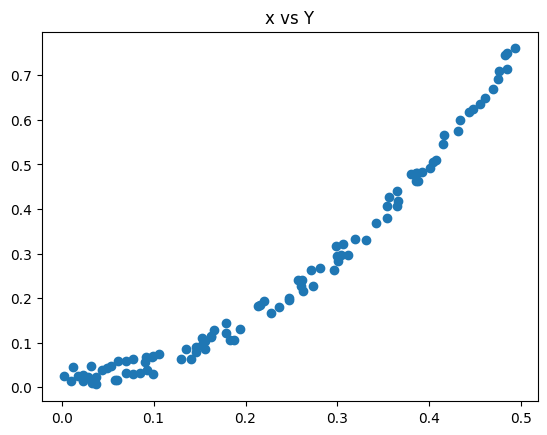

In [56]:
#genarate the PLt
plt.scatter(df['x'],df['y'])
plt.title('x vs Y')


MODEL1

In [57]:
df['pred'] =df['y'].mean()
print("Model1: ", df)

Model1:             x         y      pred
0   0.187270  0.106782  0.256405
1   0.475357  0.709714  0.256405
2   0.365997  0.417579  0.256405
3   0.299329  0.294223  0.256405
4   0.078009  0.063635  0.256405
..       ...       ...       ...
95  0.246898  0.200336  0.256405
96  0.261366  0.241235  0.256405
97  0.213771  0.181949  0.256405
98  0.012710  0.044839  0.256405
99  0.053946  0.047724  0.256405

[100 rows x 3 columns]


In [58]:
df['res/loss'] = df['y'] - df['pred']

In [59]:
df

,x,y,pred,res/loss
0,0.187270,0.106782,0.256405,-0.149624
1,0.475357,0.709714,0.256405,0.453309
2,0.365997,0.417579,0.256405,0.161174
3,0.299329,0.294223,0.256405,0.037817
4,0.078009,0.063635,0.256405,-0.192771
...,...,...,...,...
95,0.246898,0.200336,0.256405,-0.056069
96,0.261366,0.241235,0.256405,-0.015170
97,0.213771,0.181949,0.256405,-0.074456
98,0.012710,0.044839,0.256405,-0.211566


Model2

In [60]:
from sklearn.tree import DecisionTreeRegressor as DT
tree1 = DT(max_leaf_nodes = 10)
tree1.fit(df['x'].values.reshape(100,1),df['res/loss'].values)

DecisionTreeRegressor(max_leaf_nodes=10)

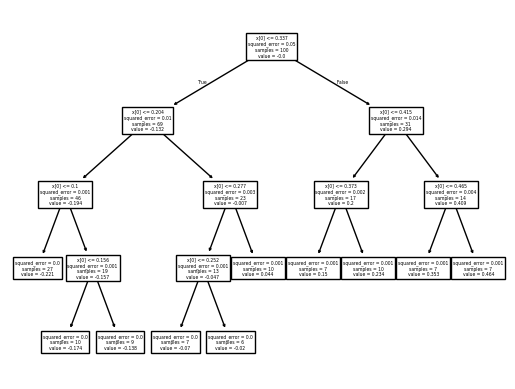

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(tree1)
plt.show()

In [62]:
x_test = np.linspace(-0.5,0.5,500)

MODEL2

In [64]:
df['y_pred2'] = df['y'].mean() + tree1.predict(df['x'].values.reshape(-1,1))

In [65]:
df['y_pred2']

,y_pred2
0,0.118878
1,0.720242
2,0.406796
3,0.300512
4,0.035602
...,...
95,0.186279
96,0.235973
97,0.186279
98,0.035602


Graph


In [66]:
df['res2'] = df['y'] - df['y_pred2']

In [67]:
df.head()

,x,y,pred,res/loss,y_pred2,res2
0,0.187270,0.106782,0.256405,-0.149624,0.118878,-0.012096
1,0.475357,0.709714,0.256405,0.453309,0.720242,-0.010528
2,0.365997,0.417579,0.256405,0.161174,0.406796,0.010783
3,0.299329,0.294223,0.256405,0.037817,0.300512,-0.006289
4,0.078009,0.063635,0.256405,-0.192771,0.035602,0.028033


In [72]:
#model3
tree2 = DT(max_leaf_nodes=8)
tree2.fit(df['x'].values.reshape(100,1),df['res2'].values)


DecisionTreeRegressor(max_leaf_nodes=8)

In [75]:
df['y_pred3'] = df['y'].mean() + sum (regressor.predict(df['x'].values.reshape(-1,1)) for regressor in [tree1,tree2])

In [76]:
df

,x,y,pred,res/loss,y_pred2,res2,y_pred3
0,0.187270,0.106782,0.256405,-0.149624,0.118878,-0.012096,0.119891
1,0.475357,0.709714,0.256405,0.453309,0.720242,-0.010528,0.690374
2,0.365997,0.417579,0.256405,0.161174,0.406796,0.010783,0.407809
3,0.299329,0.294223,0.256405,0.037817,0.300512,-0.006289,0.301525
4,0.078009,0.063635,0.256405,-0.192771,0.035602,0.028033,0.036615
...,...,...,...,...,...,...,...
95,0.246898,0.200336,0.256405,-0.056069,0.186279,0.014057,0.187292
96,0.261366,0.241235,0.256405,-0.015170,0.235973,0.005262,0.236987
97,0.213771,0.181949,0.256405,-0.074456,0.186279,-0.004330,0.187292
98,0.012710,0.044839,0.256405,-0.211566,0.035602,0.009237,0.023669
